# Telco Customer Churn

Projet de préparation et nettoyage de données.

L'objectif est de transformer un dataset brut en un jeu de données exploitable pour des algorithmes de Machine Learning.

## Phase 0 : Chargement du dataset

Avant toute opération de nettoyage, il est nécessaire d'examiner la structure générale du jeu de données.

Cette première étape permet de vérifier que les données sont correctement chargées et d'obtenir une première vue des variables disponibles.

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Phase 1 : Audit qualité

Avant toute opération de nettoyage, il est nécessaire d'établir un état des lieux du dataset.

L'objectif est d'identifier les éventuels problèmes de qualité des données et d'observer la répartition de la variable cible `Churn`.

In [6]:
def audit_qualite(df):

    print(f"Forme : {df.shape}")

    print("\nTypes des colonnes :")
    print(df.dtypes)

    taux_manquants = (
        df.isna()
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print("\nPourcentage de valeurs manquantes :")
    print(taux_manquants[taux_manquants > 0])

    repartition = df["Churn"].value_counts()
    pourcentage = df["Churn"].value_counts(normalize=True) * 100

    print("\nRépartition de Churn :")

    for valeur in repartition.index:
        print(
            f"Churn {valeur} : "
            f"{repartition[valeur]} "
            f"({pourcentage[valeur]:.1f}%)"
        )

In [7]:
audit_qualite(df)

Forme : (7043, 21)

Types des colonnes :
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Pourcentage de valeurs manquantes :
Series([], dtype: float64)

Répartition de Churn :
Churn No : 5174 (73.5%)
Churn Yes : 1869 (26.5%)


### Première lecture

Ce rapport permet d'identifier rapidement les caractéristiques générales du dataset ainsi que l'équilibre de la variable cible.

La répartition de `Churn` sera particulièrement importante lors des futures phases de modélisation.

### Observation

Une anomalie apparaît dans les types de données : la variable `TotalCharges` est interprétée comme du texte (`str`) alors qu'elle représente un montant.

Cela suggère la présence de valeurs non numériques ou de données manquantes déguisées, qui devront être investiguées avant toute modélisation.

In [8]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

### Investigation complémentaire

L'audit n'a révélé aucune valeur manquante au sens de Pandas.

Cependant, la colonne `TotalCharges` est interprétée comme du texte alors qu'elle représente un montant.

Une vérification supplémentaire montre que 11 lignes contiennent une chaîne vide après suppression des espaces.

Ces valeurs constituent probablement des données manquantes déguisées qui devront être traitées avant toute modélisation.

In [9]:
df_churn_yes = df[df["Churn"] == "Yes"]

audit_qualite(df_churn_yes)

Forme : (1869, 21)

Types des colonnes :
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Pourcentage de valeurs manquantes :
Series([], dtype: float64)

Répartition de Churn :
Churn Yes : 1869 (100.0%)


In [10]:
df_desequilibre = pd.concat(
    [
        df[df["Churn"] == "No"],
        df[df["Churn"] == "Yes"].sample(
            50,
            random_state=42
        )
    ]
)

audit_qualite(df_desequilibre)

Forme : (5224, 21)

Types des colonnes :
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Pourcentage de valeurs manquantes :
Series([], dtype: float64)

Répartition de Churn :
Churn No : 5174 (99.0%)
Churn Yes : 50 (1.0%)


### Validation de l'audit

Les différents scénarios testés montrent que la fonction reste stable lorsque la distribution de la cible change fortement.

Le déséquilibre artificiellement créé apparaît immédiatement dans le rapport, ce qui permettra d'anticiper certains biais lors de l'entraînement des modèles.

L'audit a également permis d'identifier une anomalie sur la colonne `TotalCharges`, révélant la présence de valeurs manquantes déguisées qui ne sont pas détectées par les fonctions classiques de Pandas.

## Phase 2 : Réparation de la colonne `TotalCharges`

L'audit précédent a mis en évidence une anomalie sur la colonne `TotalCharges`.

Bien qu'elle représente un montant, Pandas l'interprète comme du texte. Une investigation complémentaire a révélé la présence de valeurs vides dissimulées sous forme d'espaces.

L'objectif de cette phase est de convertir cette colonne en numérique et de traiter les valeurs manquantes ainsi révélées.

In [11]:
def reparer_total_charges(df):

    df = df.copy()

    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    nb_nan = df["TotalCharges"].isna().sum()

    print(f"Valeurs manquantes révélées : {nb_nan}")

    mediane = df["TotalCharges"].median()

    df["TotalCharges"] = df["TotalCharges"].fillna(
        mediane
    )

    print(
        f"Type final : {df['TotalCharges'].dtype}"
    )

    return df

In [12]:
df = reparer_total_charges(df)

Valeurs manquantes révélées : 11
Type final : float64


### Choix effectué

La conversion numérique révèle 11 valeurs manquantes qui étaient masquées par des chaînes contenant uniquement des espaces.

Ces valeurs ont été remplacées par la médiane de la colonne.

Ce choix permet de conserver les 7043 observations du dataset tout en limitant l'influence des valeurs extrêmes.

## Phase 3 : Encodage des variables catégorielles

La majorité des algorithmes de Machine Learning nécessitent des données numériques.

Cette étape consiste à transformer les variables textuelles du dataset en variables exploitables par un modèle tout en conservant l'information utile à la prédiction du churn.

In [13]:
def encoder_features(df):

    df = df.copy()

    # Suppression de l'identifiant client
    df = df.drop(columns=["customerID"])

    colonnes_objet = (
        df.select_dtypes(include=["object"])
        .columns
        .tolist()
    )

    colonnes_objet.remove("Churn")

    colonnes_binaires = []

    for colonne in colonnes_objet:

        if df[colonne].nunique() == 2:
            colonnes_binaires.append(colonne)

    # Encodage des colonnes binaires
    for colonne in colonnes_binaires:

        valeurs = sorted(
            df[colonne]
            .dropna()
            .unique()
        )

        mapping = {
            valeurs[0]: 0,
            valeurs[1]: 1
        }

        df[colonne] = df[colonne].map(mapping)

    # Colonnes à plusieurs modalités
    colonnes_nominales = [
        col
        for col in colonnes_objet
        if col not in colonnes_binaires
    ]

    df = pd.get_dummies(
        df,
        columns=colonnes_nominales,
        drop_first=True,
        dtype=int
    )

    # Encodage de la cible
    df["Churn"] = df["Churn"].map({
        "No": 0,
        "Yes": 1
    })

    return df

In [14]:
df_encode = encoder_features(df)

df_encode.head()

C:\Users\guder\AppData\Local\Temp\ipykernel_22948\2088662894.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=["object"])


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [15]:
print("Forme finale :", df_encode.shape)

print(
    "Colonnes texte restantes :",
    len(
        df_encode.select_dtypes(
            include="object"
        ).columns
    )
)

Forme finale : (7043, 31)
Colonnes texte restantes : 0


In [16]:
df_encode.dtypes.value_counts()

int64      29
float64     2
Name: count, dtype: int64

### Choix d'encodage

Les variables binaires ont été transformées en 0 et 1.

Les variables comportant plusieurs modalités ont été encodées à l'aide du One-Hot Encoding afin de conserver l'information sans introduire d'ordre artificiel entre les catégories.

La colonne `customerID` a été supprimée car il s'agit d'un identifiant technique propre à chaque client. Cette information n'apporte aucune valeur prédictive pour le modèle.

### Cas particulier : la variable Contract

La variable `Contract` possède les modalités :

- Month-to-month
- One year
- Two year

Même si ces catégories semblent liées à une durée, elles représentent avant tout différents types de contrats.

Un encodage One-Hot a donc été retenu afin d'éviter d'imposer arbitrairement une distance numérique entre les modalités.

### Validation de l'encodage

L'ensemble des variables catégorielles a été transformé en variables numériques.

Aucune colonne de type texte n'est présente dans le dataset final, ce qui le rend directement exploitable par les algorithmes de Machine Learning.

L'application du One-Hot Encoding augmente naturellement le nombre de colonnes, certaines variables étant désormais représentées par plusieurs indicateurs binaires.

## Phase 4 : Détection des valeurs aberrantes

Les variables numériques peuvent contenir des observations très éloignées du reste des données.

Avant de modifier ou supprimer ces valeurs, il est nécessaire de vérifier si elles correspondent réellement à des erreurs ou si elles représentent des cas métiers légitimes.

In [17]:
import matplotlib.pyplot as plt

In [18]:
def detecter_outliers_iqr(df, colonne):

    q1 = df[colonne].quantile(0.25)
    q3 = df[colonne].quantile(0.75)

    iqr = q3 - q1

    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    nb_outliers = (
        (
            df[colonne] < borne_basse
        )
        |
        (
            df[colonne] > borne_haute
        )
    ).sum()

    return (
        borne_basse,
        borne_haute,
        nb_outliers
    )

In [19]:
colonnes_numeriques = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for colonne in colonnes_numeriques:

    borne_basse, borne_haute, nb_outliers = (
        detecter_outliers_iqr(
            df_encode,
            colonne
        )
    )

    print(f"\n{colonne}")
    print(f"Borne basse : {borne_basse:.2f}")
    print(f"Borne haute : {borne_haute:.2f}")
    print(f"Outliers : {nb_outliers}")


tenure
Borne basse : -60.00
Borne haute : 124.00
Outliers : 0

MonthlyCharges
Borne basse : -46.02
Borne haute : 171.38
Outliers : 0

TotalCharges
Borne basse : -4674.34
Borne haute : 8863.16
Outliers : 0


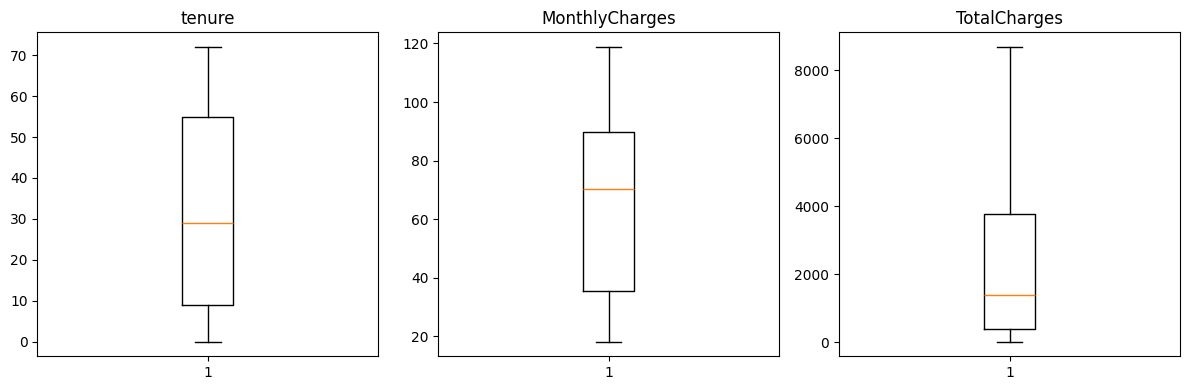

In [20]:
colonnes_numeriques = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

plt.figure(figsize=(12, 4))

for i, colonne in enumerate(colonnes_numeriques, start=1):

    plt.subplot(1, 3, i)

    plt.boxplot(df_encode[colonne])

    plt.title(colonne)

plt.tight_layout()
plt.show()

### Résultats de la détection

La méthode IQR n'a détecté aucune valeur aberrante sur les trois variables numériques étudiées :

- tenure
- MonthlyCharges
- TotalCharges

Les boxplots confirment cette observation puisqu'aucun point n'apparaît en dehors des moustaches.

Les valeurs les plus élevées observées dans le dataset semblent donc correspondre à des situations métier plausibles plutôt qu'à des erreurs de saisie.

### Décision retenue

Aucune suppression n'a été réalisée.

La méthode IQR n'identifie aucune observation comme aberrante. Supprimer des données dans ce contexte n'aurait donc aucun fondement statistique.

Les variables numériques semblent cohérentes avec la réalité métier du problème étudié.

## Phase 5 : Corrélations et multicolinéarité

Certaines variables peuvent transporter une information très proche voire redondante.

Cette phase vise à identifier les corrélations importantes entre les variables numériques et à mesurer leur impact à l'aide du Variance Inflation Factor (VIF).

In [21]:
import seaborn as sns

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

In [22]:
def rapport_multicolinearite(
    df,
    colonnes_num
):

    # Heatmap des corrélations

    correlation = (
        df[colonnes_num]
        .corr()
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        correlation,
        annot=True,
        cmap="coolwarm"
    )

    plt.title(
        "Matrice de corrélation"
    )

    plt.show()

    # Calcul du VIF

    vif = pd.DataFrame()

    vif["Variable"] = colonnes_num

    vif["VIF"] = [
        variance_inflation_factor(
            df[colonnes_num].values,
            i
        )
        for i in range(
            len(colonnes_num)
        )
    ]

    print("\nTableau des VIF :")
    print(vif)

    print("\nVariables avec VIF > 5 :")

    print(
        vif[
            vif["VIF"] > 5
        ]
    )

    return vif

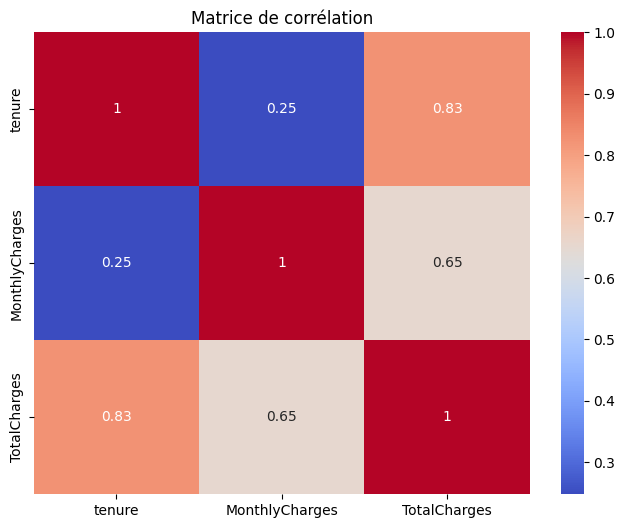


Tableau des VIF :
         Variable       VIF
0          tenure  6.321802
1  MonthlyCharges  3.360371
2    TotalCharges  8.073814

Variables avec VIF > 5 :
       Variable       VIF
0        tenure  6.321802
2  TotalCharges  8.073814


In [23]:
colonnes_numeriques = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

vif = rapport_multicolinearite(
    df_encode,
    colonnes_numeriques
)

In [24]:
print(vif)

         Variable       VIF
0          tenure  6.321802
1  MonthlyCharges  3.360371
2    TotalCharges  8.073814


In [25]:
colonnes_sans_total = [
    "tenure",
    "MonthlyCharges"
]

vif_sans_total = pd.DataFrame()

vif_sans_total["Variable"] = colonnes_sans_total

vif_sans_total["VIF"] = [
    variance_inflation_factor(
        df_encode[colonnes_sans_total].values,
        i
    )
    for i in range(
        len(colonnes_sans_total)
    )
]

print(vif_sans_total)

         Variable       VIF
0          tenure  2.612607
1  MonthlyCharges  2.612607


### Analyse de la multicolinéarité

La matrice de corrélation met en évidence une forte relation entre `TotalCharges` et `tenure` (0.83), ainsi qu'une corrélation notable entre `TotalCharges` et `MonthlyCharges` (0.65).

Le calcul du VIF confirme cette observation :

- tenure : 6.32
- MonthlyCharges : 3.36
- TotalCharges : 8.07

Les variables `tenure` et `TotalCharges` dépassent le seuil de 5 généralement utilisé pour signaler une multicolinéarité importante.

Cette situation est cohérente avec la nature des données puisque le montant total facturé dépend fortement de l'ancienneté du client et de ses factures mensuelles.

### Décision retenue

La variable `TotalCharges` a été supprimée afin de réduire la redondance d'information.

Cette variable n'apporte pas réellement une nouvelle information puisqu'elle est largement déterminée par :

- `tenure`
- `MonthlyCharges`

Après suppression de `TotalCharges`, les VIF restants deviennent :

- tenure : 2.61
- MonthlyCharges : 2.61

Le problème de multicolinéarité disparaît donc tout en conservant les informations essentielles du dataset.

In [26]:
df_final = df_encode.drop(
    columns=["TotalCharges"]
)

df_final.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,0,1,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,0,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,1,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,0,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,1,0,...,0,0,0,0,0,0,0,0,1,0


## Phase 6 : Identification des variables les plus prédictives

Toutes les variables ne contribuent pas de la même manière à la prédiction du churn.

Cette phase vise à identifier les caractéristiques les plus influentes en combinant deux approches :

- la corrélation avec la cible ;
- l'importance calculée par une Random Forest.

L'objectif est de comparer les résultats obtenus et de vérifier si les deux méthodes racontent une histoire cohérente.

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [2]:
def features_discriminantes(
    df,
    cible="Churn"
):

    X = df.drop(columns=[cible])
    y = df[cible]

    # Corrélation avec la cible

    correlations = (
        X.corrwith(y)
        .abs()
        .sort_values(
            ascending=False
        )
    )

    top_corr = (
        correlations
        .head(10)
        .reset_index()
    )

    top_corr.columns = [
        "Feature",
        "Correlation"
    ]

    # Random Forest

    rf = RandomForestClassifier(
        random_state=42
    )

    rf.fit(X, y)

    importances = pd.Series(
        rf.feature_importances_,
        index=X.columns
    )

    top_rf = (
        importances
        .sort_values(
            ascending=False
        )
        .head(10)
        .reset_index()
    )

    top_rf.columns = [
        "Feature",
        "Importance"
    ]

    print("Top 10 Corrélations")
    print(top_corr)

    print("\nTop 10 Random Forest")
    print(top_rf)

    return top_corr, top_rf

In [28]:
top_corr, top_rf = features_discriminantes(
    df_final
)

Top 10 Corrélations
                                Feature  Correlation
0                                tenure     0.352229
1           InternetService_Fiber optic     0.308020
2                     Contract_Two year     0.302253
3        PaymentMethod_Electronic check     0.301919
4                    InternetService_No     0.227890
5  DeviceProtection_No internet service     0.227890
6       TechSupport_No internet service     0.227890
7   StreamingMovies_No internet service     0.227890
8       StreamingTV_No internet service     0.227890
9    OnlineSecurity_No internet service     0.227890

Top 10 Random Forest
                          Feature  Importance
0                          tenure    0.246036
1                  MonthlyCharges    0.232120
2     InternetService_Fiber optic    0.044536
3  PaymentMethod_Electronic check    0.038306
4               Contract_Two year    0.036913
5                          gender    0.033228
6                PaperlessBilling    0.029346
7      

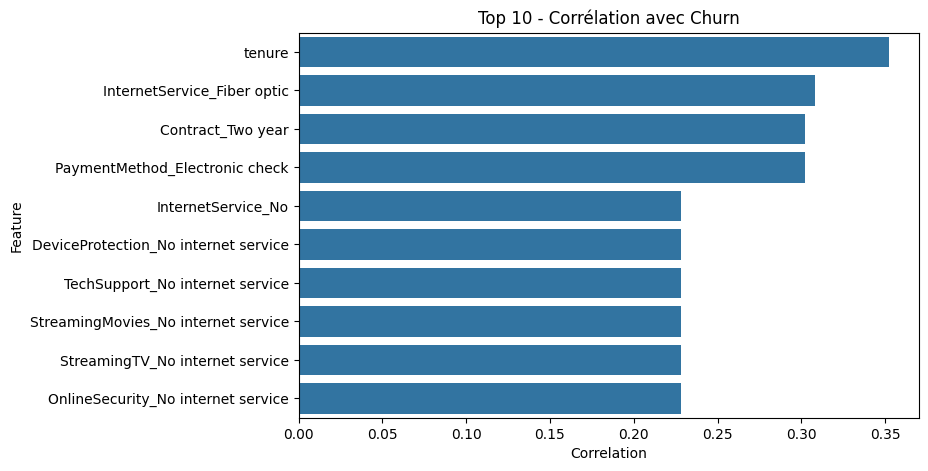

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_corr,
    x="Correlation",
    y="Feature"
)

plt.title(
    "Top 10 - Corrélation avec Churn"
)

plt.show()

### Interprétation

Les deux méthodes permettent d'identifier les variables les plus influentes dans la prédiction du churn.

La corrélation mesure uniquement les relations linéaires directes avec la cible tandis que la Random Forest est capable de détecter des relations plus complexes.

Comparer les deux classements permet d'obtenir une vision plus robuste des facteurs associés à la résiliation.*

### Analyse des résultats

Les deux méthodes identifient plusieurs variables communes parmi les plus importantes :

- `tenure`
- `InternetService_Fiber optic`
- `PaymentMethod_Electronic check`
- `Contract_Two year`

La variable `tenure` arrive en première position dans les deux classements, ce qui suggère que l'ancienneté du client est l'un des principaux facteurs associés au churn.

Les résultats montrent également que les clients disposant d'un contrat long ont tendance à moins résilier que ceux engagés sur des contrats plus courts.

Une différence apparaît toutefois pour `MonthlyCharges`. Cette variable est fortement valorisée par la Random Forest mais n'apparaît pas parmi les premières corrélations.

Cela suggère qu'une partie de son pouvoir prédictif repose sur des relations non linéaires ou sur des interactions avec d'autres variables, phénomènes que la corrélation ne permet pas de capturer.

## Phase 7 : Split, scaling et prévention des fuites de données

L'ordre des opérations de prétraitement est essentiel pour obtenir une évaluation fiable d'un modèle.

Dans cette phase, le scaling sera réalisé de deux façons :

- une version correcte où le scaler est ajusté uniquement sur les données d'entraînement ;
- une version contenant une fuite de données où le scaler est ajusté sur l'ensemble du dataset avant le découpage.

Les résultats seront ensuite comparés.

In [31]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [32]:
def split_et_scale_proprement(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    return (
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

In [33]:
X = df_final.drop(
    columns=["Churn"]
)

y = df_final["Churn"]

### Version Honnete : 

In [34]:
(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
) = split_et_scale_proprement(
    X,
    y
)

modele = LogisticRegression(
    max_iter=10000
)

modele.fit(
    X_train_scaled,
    y_train
)

predictions = modele.predict(
    X_test_scaled
)

accuracy_propre = accuracy_score(
    y_test,
    predictions
)

print(
    f"Accuracy propre : {accuracy_propre:.4f}"
)

Accuracy propre : 0.7977


### Version Triche

In [36]:
scaler = StandardScaler()

X_scale_triche = scaler.fit_transform(
    X
)

(
    X_train_triche,
    X_test_triche,
    y_train_triche,
    y_test_triche
) = train_test_split(
    X_scale_triche,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

modele_triche = LogisticRegression(
    max_iter=10000
)

modele_triche.fit(
    X_train_triche,
    y_train_triche
)

predictions_triche = modele_triche.predict(
    X_test_triche
)

accuracy_triche = accuracy_score(
    y_test_triche,
    predictions_triche
)

print(
    f"Accuracy triche : {accuracy_triche:.4f}"
)

Accuracy triche : 0.7970


In [37]:
print(
    f"Delta : {accuracy_triche - accuracy_propre:.4f}"
)

Delta : -0.0007


### Analyse

La version correcte ajuste le scaler uniquement sur les données d'entraînement puis applique cette transformation aux données de test.

La version contenant une fuite de données ajuste le scaler sur l'ensemble du dataset avant le découpage train/test, ce qui introduit une information provenant du jeu de test dans le prétraitement.

Dans notre expérimentation, l'écart observé entre les deux approches est extrêmement faible (delta ≈ -0.0007). La fuite de données n'apporte donc aucun gain visible sur ce dataset.

Ce résultat ne signifie pas que la pratique est acceptable. Avec un dataset de grande taille et relativement homogène comme Telco Customer Churn, les statistiques utilisées par le scaler sont très proches entre le train et le test, ce qui limite l'impact de la fuite.

La leçon principale reste la même : toutes les opérations qui apprennent des informations à partir des données doivent être ajustées sur le jeu d'entraînement uniquement. Même lorsqu'une fuite semble sans conséquence, elle fausse la méthodologie expérimentale et peut produire des résultats trompeurs sur d'autres jeux de données.